In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import Sequential, Input, optimizers, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import os
import random

# --- 1. Configuration & Reproducibility ---
# Best Parameters from LSTM Trial 48
BEST_PARAMS = {
    'lookback': 30,
    'batch_size': 32,
    'epochs': 100,
    'patience': 9,
    'num_layers': 1,
    'units1': 256,
    'dropout': 0.0212, # Rounded from 0.021179...
    'lr': 0.0025       # Rounded from 0.002478...
}

CSV_PATH = "ALL_MERGED.csv"  # Ensure this matches your file name
TARGET_COL = "JKSE"
RANDOM_SEED = 271828183

print(f"Setting Random Seed: {RANDOM_SEED}")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

Setting Random Seed: 271828183


In [2]:
# --- 2. Data Loading & Preprocessing ---
def load_and_process_data(csv_path, target_col):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found. Please upload the dataset.")
        return None, None, None, None

    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df = df.ffill().bfill()
    
    # Split Data
    n = len(df)
    test_n = int(np.floor(0.20 * n))
    val_n = int(np.floor(0.10 * (n - test_n)))
    train_n = n - test_n - val_n
    
    train_df = df.iloc[:train_n]
    val_df = df.iloc[train_n:train_n + val_n]
    test_df = df.iloc[train_n + val_n:]
    
    # Scaling
    feature_cols = df.columns.tolist()
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    X_scaler.fit(train_df[feature_cols])
    y_scaler.fit(train_df[[target_col]])
    
    def scale_df(d):
        return X_scaler.transform(d[feature_cols]), y_scaler.transform(d[[target_col]]).flatten()
    
    X_train_s, y_train_s = scale_df(train_df)
    X_val_s, y_val_s = scale_df(val_df)
    X_test_s, y_test_s = scale_df(test_df)
    
    return (X_train_s, y_train_s, train_df.index), \
           (X_val_s, y_val_s, val_df.index), \
           (X_test_s, y_test_s, test_df.index), \
           y_scaler

data_result = load_and_process_data(CSV_PATH, TARGET_COL)
if data_result[0] is None:
    raise FileNotFoundError("Data file not found.")

(X_train_s, y_train_s, idx_train), \
(X_val_s, y_val_s, idx_val), \
(X_test_s, y_test_s, idx_test), y_scaler = data_result

# Sliding Window Function
def make_windows(X, y, width):
    X_out, y_out, indices = [], [], []
    for i in range(len(X) - width):
        X_out.append(X[i : i + width])
        y_out.append(y[i + width])
        indices.append(i + width)
    return np.array(X_out), np.array(y_out), indices

lookback = BEST_PARAMS['lookback']
X_train_w, y_train_w, train_indices = make_windows(X_train_s, y_train_s, lookback)
X_val_w, y_val_w, val_indices = make_windows(X_val_s, y_val_s, lookback)
X_test_w, y_test_w, test_indices = make_windows(X_test_s, y_test_s, lookback)

In [3]:
# --- 3. LSTM Model Definition ---
def hetero_loss(y_true, y_pred):
    mean = y_pred[:, 0]
    log_var = y_pred[:, 1]
    precision = tf.exp(-log_var)
    return tf.reduce_mean(0.5 * precision * tf.square(y_true - mean) + 0.5 * log_var)

def build_lstm_model(input_shape, params):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # LSTM Layers (Based on Best Params: num_layers=1)
    if params['num_layers'] == 2:
        model.add(LSTM(params['units1'], return_sequences=True))
        model.add(Dropout(params['dropout']))
        model.add(LSTM(params['units2'], return_sequences=False))
    else:
        model.add(LSTM(params['units1'], return_sequences=False))
        
    model.add(Dropout(params['dropout']))
    
    # Heteroscedastic Head (Mean, LogVar)
    model.add(Dense(2)) 
    
    optimizer = optimizers.Adam(learning_rate=params['lr'])
    model.compile(optimizer=optimizer, loss=hetero_loss)
    
    return model

In [4]:
# --- 4. Training ---
print("\n>>> Training LSTM with Best Parameters...")
model = build_lstm_model((lookback, X_train_s.shape[1]), BEST_PARAMS)
model.summary()

history = model.fit(
    X_train_w, y_train_w,
    validation_data=(X_val_w, y_val_w),
    epochs=BEST_PARAMS['epochs'],
    batch_size=BEST_PARAMS['batch_size'],
    callbacks=[EarlyStopping(patience=BEST_PARAMS['patience'], restore_best_weights=True)],
    verbose=1
)


>>> Training LSTM with Best Parameters...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       277,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,018 (1.06 MB)

 Trainable params: 278,018 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: -0.3046 - val_loss: -0.7042
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -1.3954 - val_loss: -0.9202
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -1.7671 - val_loss: -1.2283
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: -1.8049 - val_loss: -0.9742
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -1.9463 - val_loss: -1.8791
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: -1.9246 - val_loss: -1.6738
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -1.9543 - val_loss: -1.8997
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -2.0143 - val_loss: -1.9619
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -2.0758 - val_loss: -1.8224
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -2.0796 - val_loss: -2.0445
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -2.1306 - val_loss: -2.1192
Epoch 12/100
82/82 ━━━━━━━━━━━

In [5]:
# --- 5. Last Layer Laplace Approximation (LLLA) ---
print("\n>>> Extracting Features for Laplace Approximation...")

# [FIX] Robust Feature Extractor Construction
# We create a new input and pass it through all layers EXCEPT the last one
# The last layer is 'Dense(2)' (index -1). We want the output of 'Dropout' (index -2).
new_input = Input(shape=(lookback, X_train_s.shape[1]))
x = new_input

# Loop through all layers except the last one
for layer in model.layers[:-1]:
    x = layer(x)

phi_model = Model(inputs=new_input, outputs=x)

# Extract Features (Phi)
phi_train = phi_model.predict(X_train_w, verbose=0)
phi_test = phi_model.predict(X_test_w, verbose=0)

print(f"Feature shape (Phi): {phi_train.shape}") # Should be (N, 256)

# Estimate Residual Variance (Sigma_n^2)
y_pred_train = model.predict(X_train_w, verbose=0)
mu_train = y_pred_train[:, 0]
residuals = y_train_w - mu_train
sigma_n2 = np.mean(residuals**2) 
print(f"Estimated Noise Variance (sigma_n^2): {sigma_n2:.4f}")

# Construct Hessian Matrix
N, H_dim = phi_train.shape
Phi_train_aug = np.hstack([phi_train, np.ones((N, 1))]) # Add bias column

lambda_prior = 1.0
# Full Hessian Calculation
H_full = (1.0 / sigma_n2) * (Phi_train_aug.T @ Phi_train_aug) + np.eye(H_dim + 1) * lambda_prior

# Invert for Covariance (Uncertainty)
# Add small jitter to diagonal for numerical stability if needed
jitter = 1e-6 * np.eye(H_full.shape[0])
Sigma_post = np.linalg.inv(H_full + jitter)


>>> Extracting Features for Laplace Approximation...
Feature shape (Phi): (2602, 256)
Estimated Noise Variance (sigma_n^2): 0.0045



>>> Generating Visualizations...


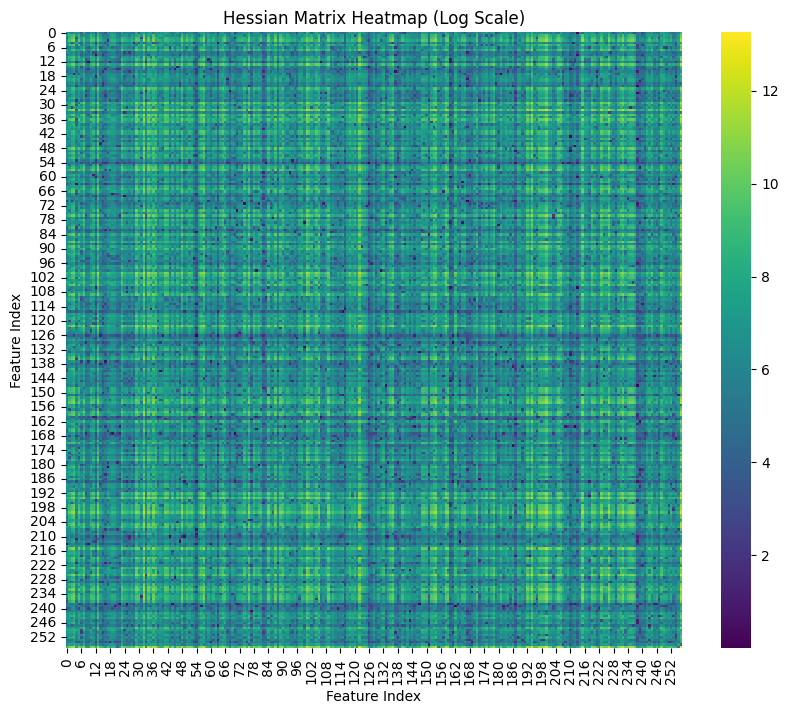

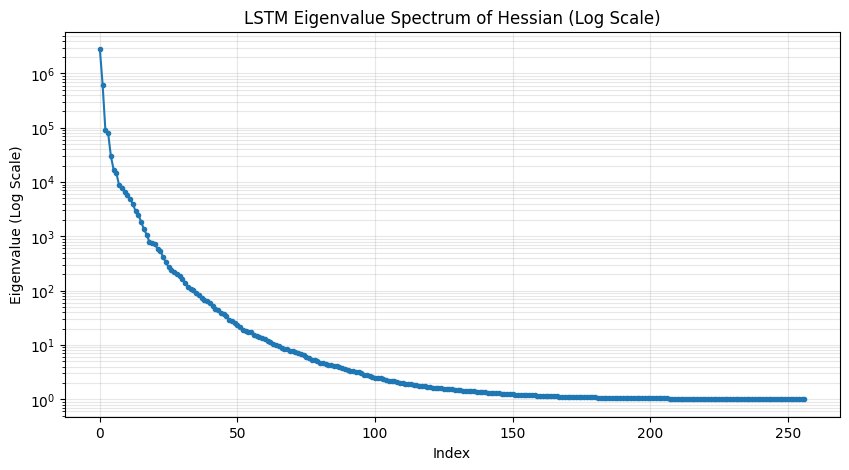

In [10]:
# --- 6. Interactive Visualization ---
print("\n>>> Generating Visualizations...")

# A. 2D Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(np.log1p(np.abs(H_full)), cmap="viridis", square=True)
plt.title("Hessian Matrix Heatmap (Log Scale)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")
plt.show()

# B. Interactive 3D Surface (Plotly)
z_data = np.log1p(np.abs(H_full))
fig = go.Figure(data=[go.Surface(z=z_data, colorscale='Viridis')])
fig.update_layout(
    title='Interactive Hessian Landscape (Log Curvature)',
    scene=dict(
        xaxis_title='Feature i',
        yaxis_title='Feature j',
        zaxis_title='Log Magnitude'
    ),
    width=800, height=600
)
fig.show()

# C. Eigenvalue Spectrum
eigvals = np.linalg.eigvalsh(H_full)
eigvals = np.sort(eigvals)[::-1]
plt.figure(figsize=(10, 5))
plt.plot(eigvals, marker='.', linestyle='-')
plt.yscale('log')
plt.title("LSTM Eigenvalue Spectrum of Hessian (Log Scale)")
plt.xlabel("Index")
plt.ylabel("Eigenvalue (Log Scale)")
plt.grid(True, which="both", alpha=0.3)
plt.show()


>>> Generating Smooth 3D Hessian (Matplotlib)...


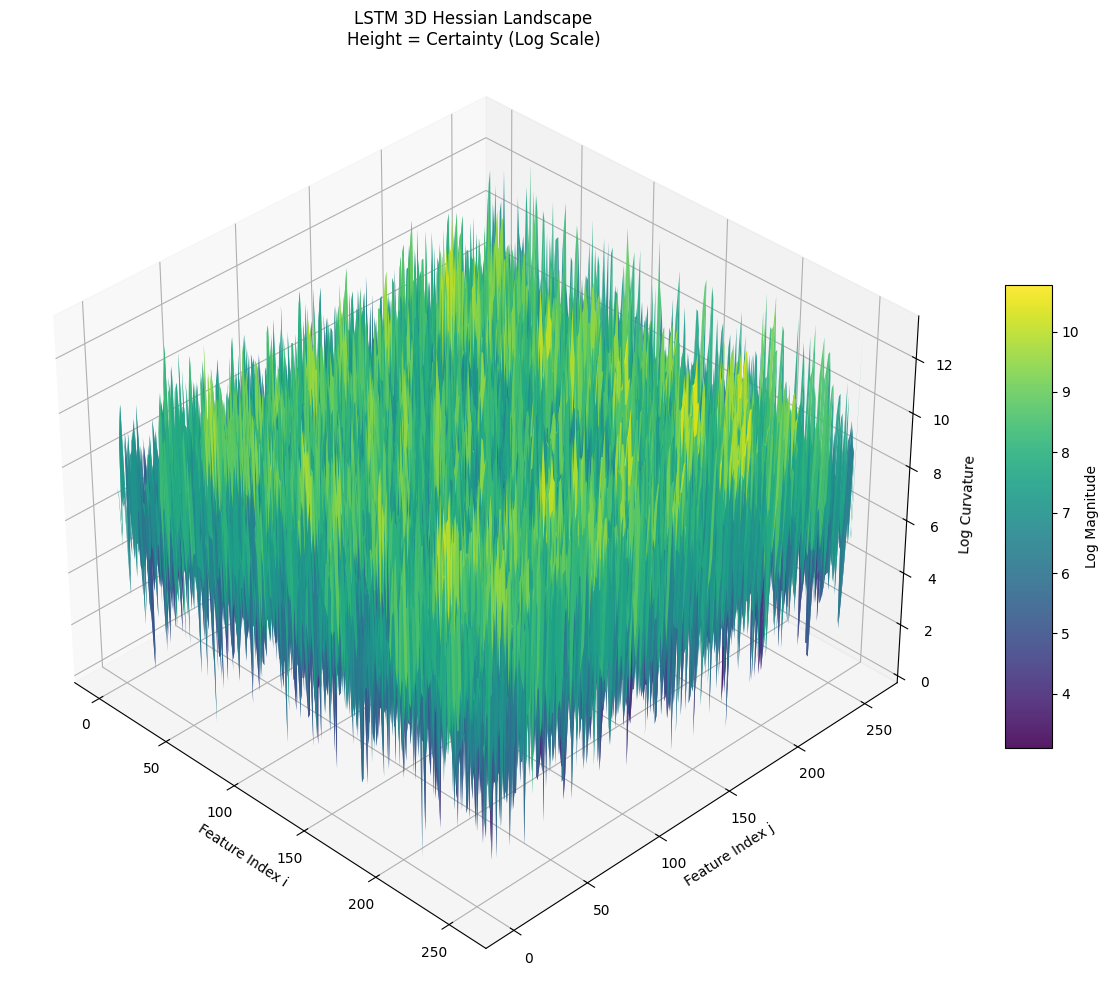

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

print("\n>>> Generating Smooth 3D Hessian (Matplotlib)...")

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Create Grid
# H_full is roughly 257x257 (256 units + 1 bias)
x = np.arange(H_full.shape[0])
y = np.arange(H_full.shape[1])
X, Y = np.meshgrid(x, y)

# 2. Data (Log Magnitude)
# We use log1p to make the "mountains" (high curvature) visible against the "valleys"
Z = np.log1p(np.abs(H_full))

# 3. Plot Surface
# rstride/cstride (row/column stride): Skips points to improve rendering speed/clarity 
# for large matrices like this one.
surf = ax.plot_surface(X, Y, Z, 
                       cmap='viridis', 
                       edgecolor='none', 
                       rstride=2, cstride=2, # Downsample slightly for smoother look
                       alpha=0.9, 
                       antialiased=True)

# 4. Labels & View
ax.set_title("LSTM 3D Hessian Landscape\nHeight = Certainty (Log Scale)")
ax.set_xlabel("Feature Index i")
ax.set_ylabel("Feature Index j")
ax.set_zlabel("Log Curvature")

# Optional: Adjust camera angle (Elevation, Azimuth)
ax.view_init(elev=35, azim=-45)

# 5. Add Colorbar
fig.colorbar(surf, shrink=0.5, aspect=10, label="Log Magnitude")

plt.tight_layout()
plt.show()

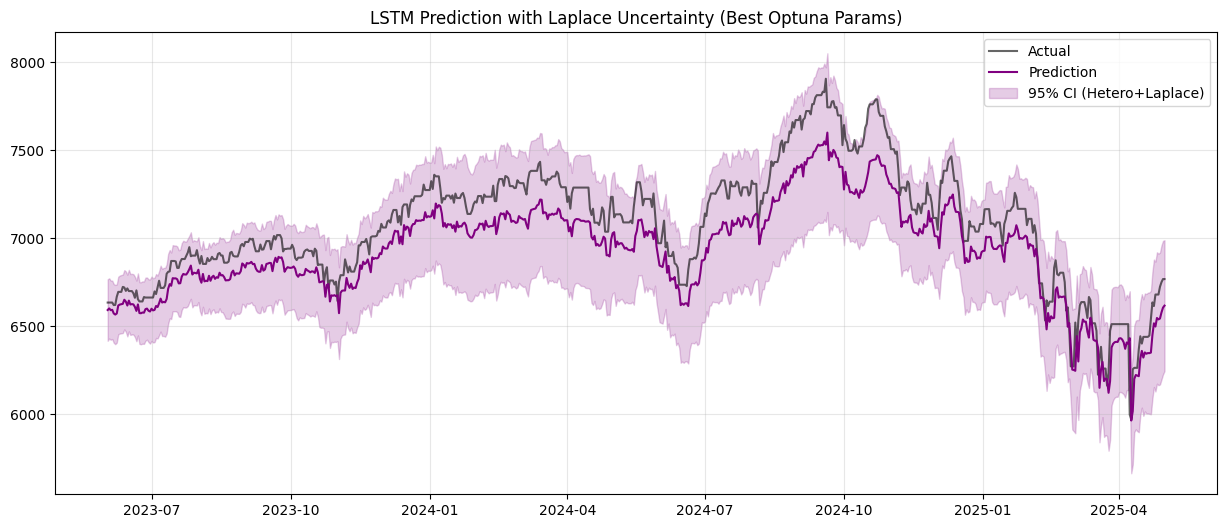

In [7]:
# --- 7. Final Inference with Uncertainty ---
y_pred_test = model.predict(X_test_w, verbose=0)
mu_test_s = y_pred_test[:, 0]
log_var_test_s = y_pred_test[:, 1]

# Aleatoric
sigma_ale_s = np.sqrt(np.exp(log_var_test_s))

# Epistemic
Phi_test_aug = np.hstack([phi_test, np.ones((phi_test.shape[0], 1))])
var_epi_s = np.sum(Phi_test_aug @ Sigma_post * Phi_test_aug, axis=1)
sigma_epi_s = np.sqrt(var_epi_s)

# Combine
sigma_total_s = np.sqrt(sigma_ale_s**2 + sigma_epi_s**2)

# Inverse Scale
y_mean = y_scaler.mean_[0]
y_std = y_scaler.scale_[0]

mu_test = mu_test_s * y_std + y_mean
sigma_total = sigma_total_s * y_std

# Plot
plt.figure(figsize=(15, 6))
# Corrected Date Indexing
test_dates = idx_test[test_indices] 

plt.plot(test_dates, y_test_w * y_std + y_mean, label="Actual", color="black", alpha=0.6)
plt.plot(test_dates, mu_test, label="Prediction", color="purple") # Purple for LSTM
plt.fill_between(test_dates, 
                 mu_test - 1.96 * sigma_total, 
                 mu_test + 1.96 * sigma_total, 
                 color="purple", alpha=0.2, label="95% CI (Hetero+Laplace)")

plt.title("LSTM Prediction with Laplace Uncertainty (Best Optuna Params)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()